In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
df=pd.read_csv("C:\\Users\ACER\Downloads\\boston_data.csv")
pd.set_option('display.max_columns', None)
pd.set_option('display.width',500)
print(df.head())

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.15876,0.0,10.81,0.0,0.413,5.961,17.5,5.2873,4.0,305.0,19.2,376.94,9.88,21.7
1,0.10328,25.0,5.13,0.0,0.453,5.927,47.2,6.9320,8.0,284.0,19.7,396.90,9.22,19.6
2,0.34940,0.0,9.90,0.0,0.544,5.972,76.7,3.1025,4.0,304.0,18.4,396.24,9.97,20.3
3,2.73397,0.0,19.58,0.0,0.871,5.597,94.9,1.5257,5.0,403.0,14.7,351.85,21.45,15.4
4,0.04337,21.0,5.64,0.0,0.439,6.115,63.0,6.8147,4.0,243.0,16.8,393.97,9.43,20.5


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404 entries, 0 to 403
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     404 non-null    float64
 1   zn       404 non-null    float64
 2   indus    404 non-null    float64
 3   chas     404 non-null    float64
 4   nox      404 non-null    float64
 5   rm       404 non-null    float64
 6   age      404 non-null    float64
 7   dis      404 non-null    float64
 8   rad      404 non-null    float64
 9   tax      404 non-null    float64
 10  ptratio  404 non-null    float64
 11  black    404 non-null    float64
 12  lstat    404 non-null    float64
 13  medv     404 non-null    float64
dtypes: float64(14)
memory usage: 44.3 KB
None


In [4]:
print(df.describe())

             crim          zn       indus        chas         nox         rm         age         dis         rad         tax     ptratio       black       lstat        medv
count  404.000000  404.000000  404.000000  404.000000  404.000000  404.00000  404.000000  404.000000  404.000000  404.000000  404.000000  404.000000  404.000000  404.000000
mean     3.730912   10.509901   11.189901    0.069307    0.556710    6.30145   68.601733    3.799666    9.836634  411.688119   18.444554  355.068243   12.598936   22.312376
std      8.943922   22.053733    6.814909    0.254290    0.117321    0.67583   28.066143    2.109916    8.834741  171.073553    2.150295   94.489572    6.925173    8.837019
min      0.006320    0.000000    0.460000    0.000000    0.392000    3.56100    2.900000    1.169100    1.000000  187.000000   12.600000    0.320000    1.730000    5.000000
25%      0.082382    0.000000    5.190000    0.000000    0.453000    5.90275   45.800000    2.087875    4.000000  281.000000   17.37500

In [5]:
print(df.isnull().sum())

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
black      0
lstat      0
medv       0
dtype: int64


<Figure size 4200x4200 with 0 Axes>

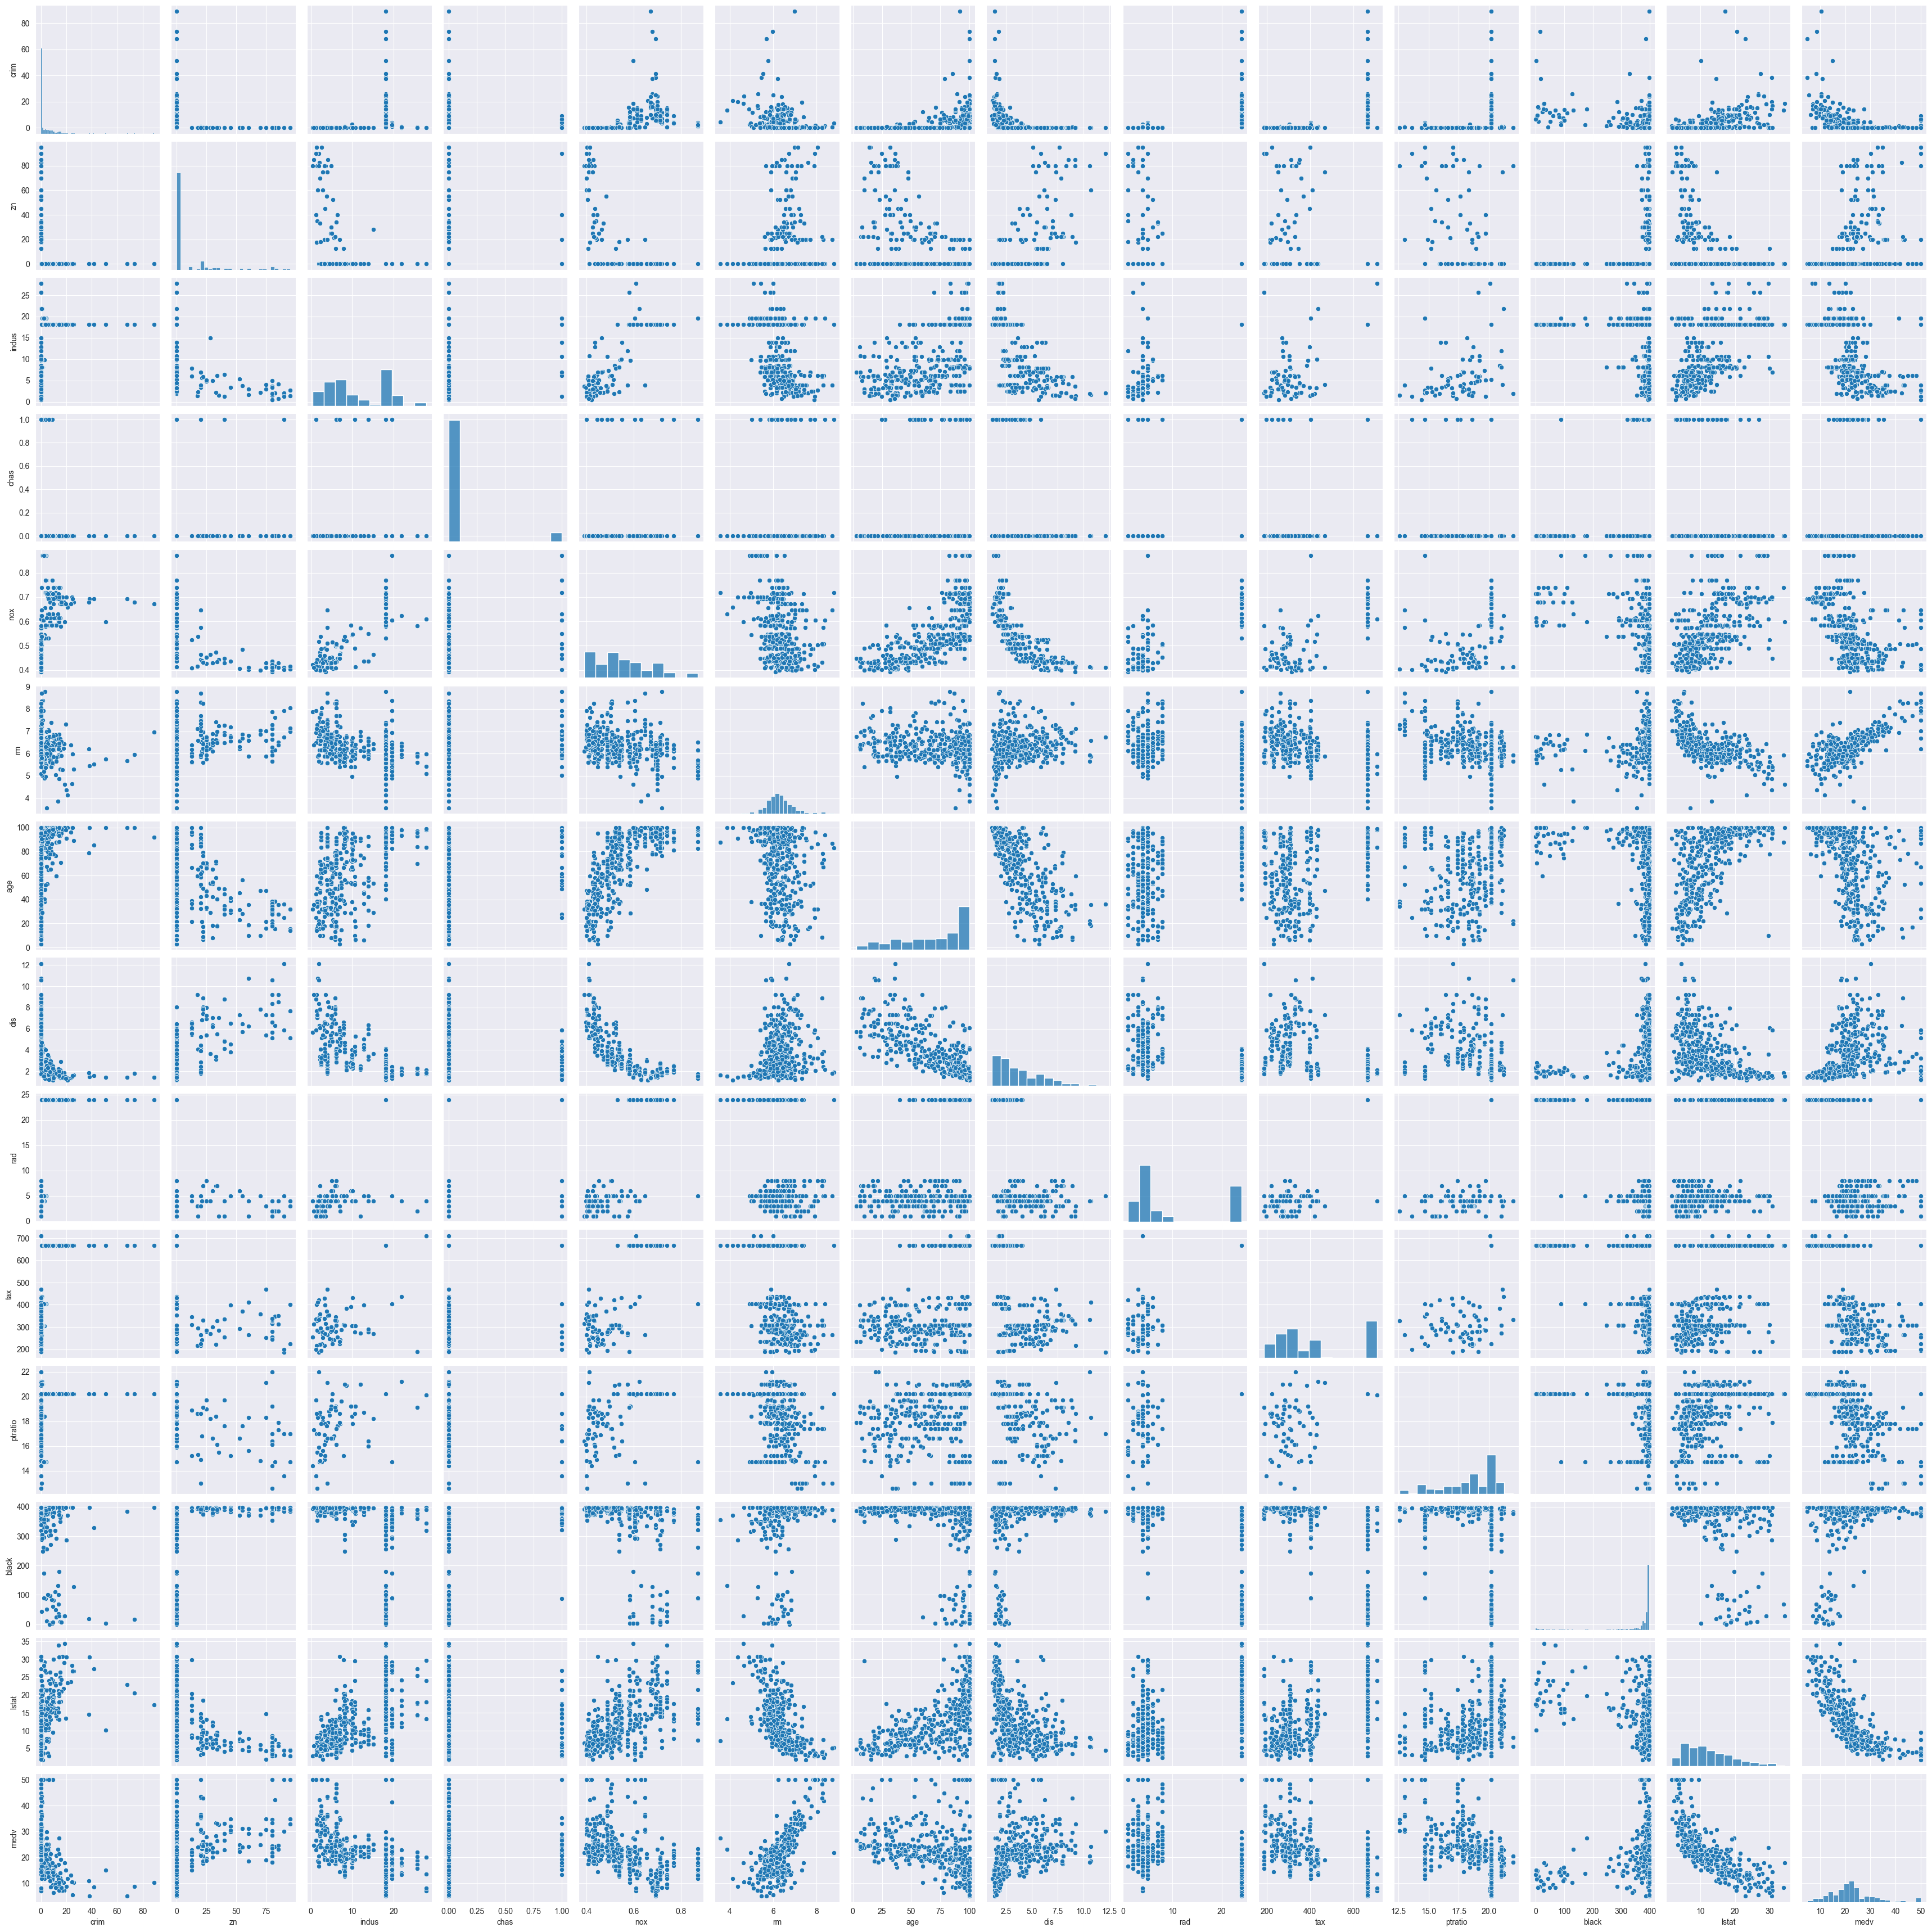

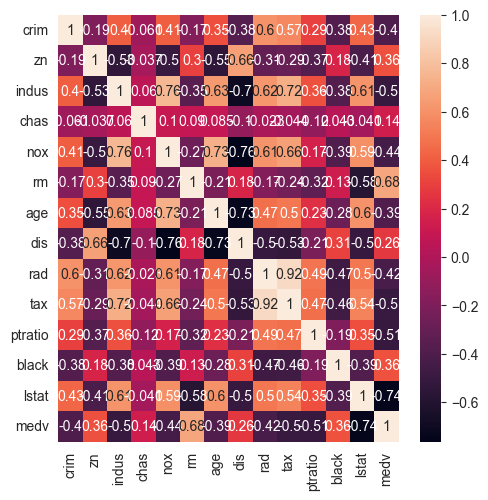

In [6]:
plt.figure(figsize=(42,42))
sns.pairplot(df)
sns.displot(df['medv'])
sns.heatmap(df.corr(),annot=True)
plt.show()

lets import libraries for ML models

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
X=df[['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax','ptratio', 'black', 'lstat']]
y=df['medv']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

linearRegression model

In [11]:
model_for_pred=LinearRegression()
scalemode=StandardScaler()

x_train_scaled=scalemode.fit_transform(x_train)
x_test=scalemode.transform(x_test)

model_for_pred.fit(x_train_scaled, y_train)
y_pred=model_for_pred.predict(x_test)
error=mean_squared_error(y_test,y_pred)
error2=mean_absolute_error(y_test,y_pred)
r2_1=r2_score(y_test,y_pred)

Ridge

In [13]:
ridge=Ridge(alpha=1.0)
ridge.fit(x_train_scaled,y_train)
y_pred2=ridge.predict(x_test)
error_of_ridge=mean_squared_error(y_test,y_pred2)
error_of_ridge2=mean_absolute_error(y_test,y_pred2)
r2_2=r2_score(y_test,y_pred2)

Random Forest

In [14]:
forest=RandomForestRegressor(random_state=42)
forest.fit(x_train_scaled,y_train)
y_pred3=forest.predict(x_test)
error_of_forest=mean_squared_error(y_test,y_pred3)
error_of_forest2=mean_absolute_error(y_test,y_pred3)
r2_3=r2_score(y_test,y_pred3)

comparison of the results of models

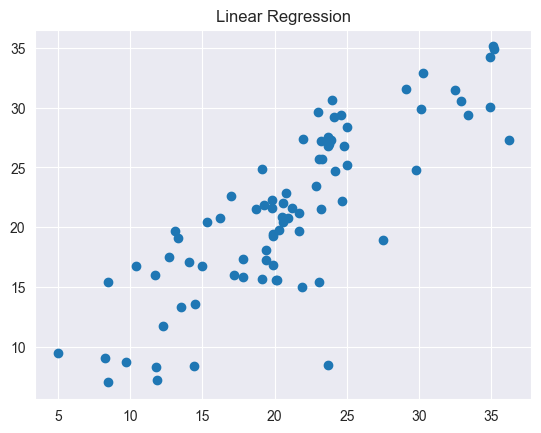

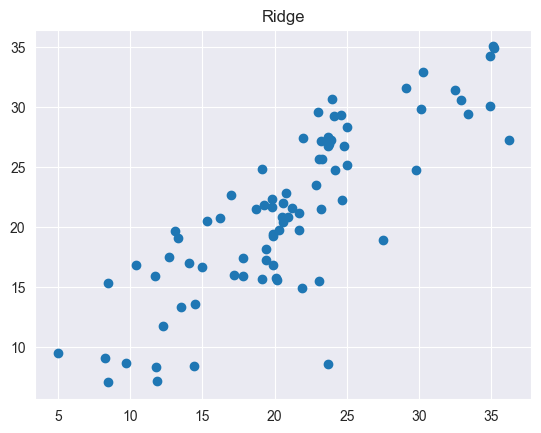

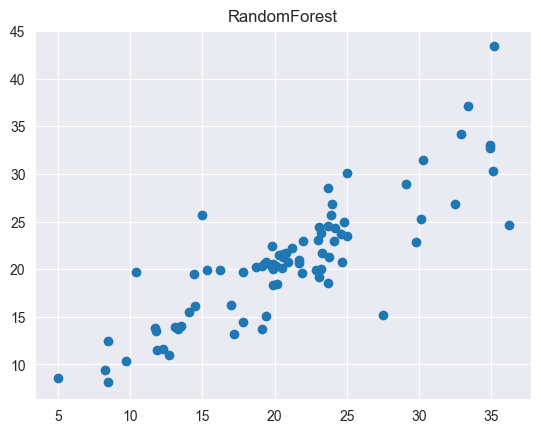

In [15]:
results = pd.DataFrame({'LinearRegressor':[error,error2,r2_1],
                        'Ridge':[error_of_ridge,error_of_ridge2,r2_2],
                        'Forest':[error_of_forest,error_of_forest2,r2_3],},
                       index=['mse','mae','r2'])
plt.figure()
plt.scatter(y_test,y_pred)
plt.title('Linear Regression')

plt.figure()
plt.scatter(y_test,y_pred2)
plt.title('Ridge')

plt.figure()
plt.scatter(y_test,y_pred3)
plt.title('RandomForest')
plt.show()

let's see the best model

In [16]:
print(results)
print('the best model:' + str(results.loc['r2'].idxmax()))

     LinearRegressor      Ridge     Forest
mse        17.007157  16.942133  13.292347
mae         3.183886   3.176975   2.545284
r2          0.639928   0.641304   0.718577
the best model:Forest
